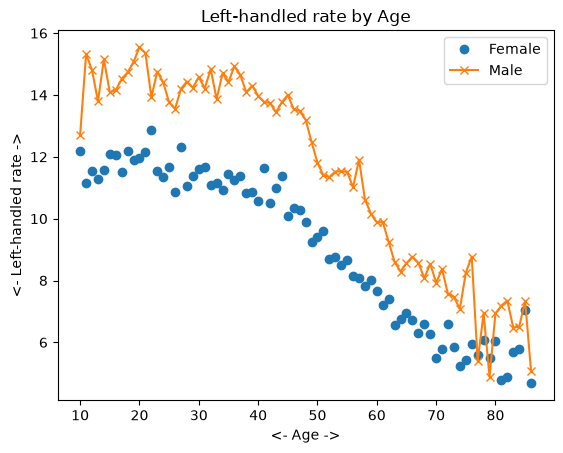

Task 1 completed successfully


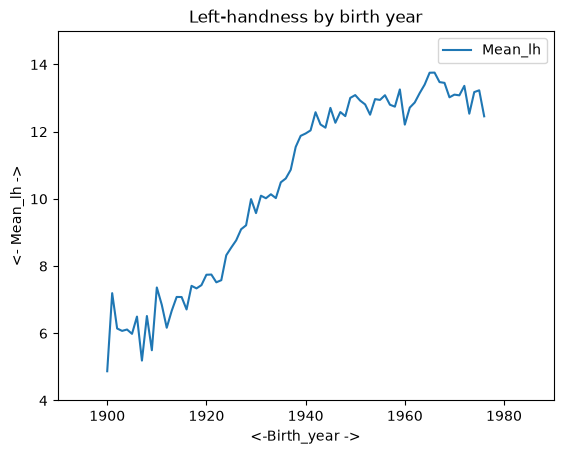

Task 2 completed successfully
Task 3 completed successfully


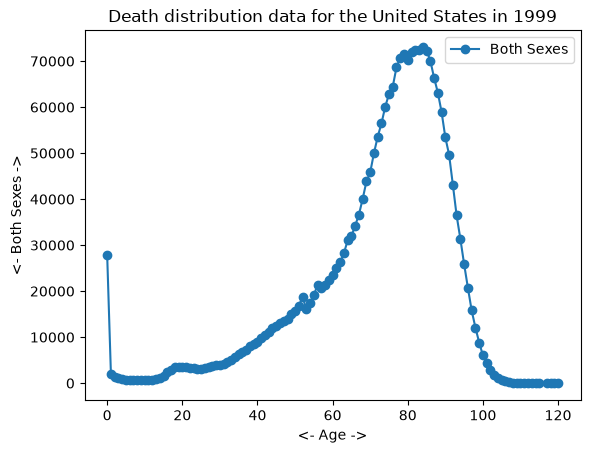

Task 4 completed successfully
Task 5 completed successfully
Task 6 completed successfully
Task 7 completed successfully


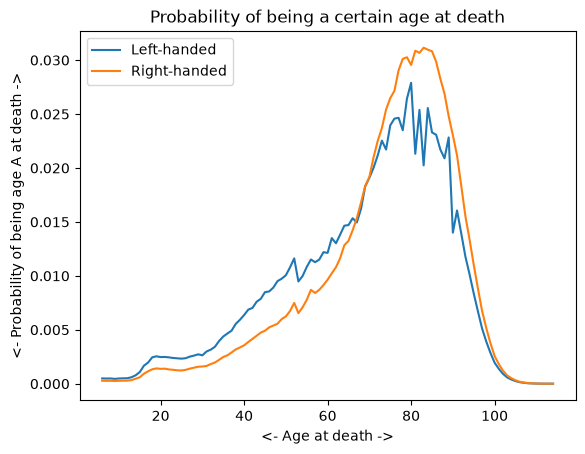

Task 8 completed successfully
Average age of lefthanded is: 67.2450366280234
Average age of righthanded is: 72.79171936526775
The difference in average ages is: 5.5 years.
Task 9 completed successfully
The difference in average ages is 2.3 years.
Task 10 completed successfully


In [1]:
# **TASK_01**
# **Load data from the National Geographic survey and create a scatter plot.**

# ... CODE FOR TASK 1 ...

import pandas as pd
import matplotlib.pyplot as plt


data_url_1 = "handedness_rate_by_age_gilbert_wysocki_1992.csv"
lefthanded_data = pd.read_csv(data_url_1)

fig, ax = plt.subplots()
# In case the CSV was loaded as a single column, split it into Age/Male/Female
if lefthanded_data.columns.tolist() == ['Age,Male,Female']:
    lefthanded_data = lefthanded_data['Age,Male,Female'].str.split(',', expand=True)
    lefthanded_data.columns = ['Age', 'Male', 'Female']
    lefthanded_data = lefthanded_data.apply(pd.to_numeric, errors='coerce')

ax.plot('Age', 'Female', data=lefthanded_data, marker='o', linestyle='None', label='Female')
ax.plot('Age', 'Male', data = lefthanded_data, marker = 'x')
ax.legend()
ax.set_xlabel('<- Age ->')
ax.set_ylabel('<- Left-handled rate ->')
plt.title('Left-handled rate by Age')
plt.show()
print("Task 1 completed successfully")

# **TASK_02**
# **Add two new columns,then plot the mean as a function of birth year.**

# ... CODE FOR TASK 2 ...
lefthanded_data['Birth_year'] = 1986 - lefthanded_data['Age']
lefthanded_data['Mean_lh'] = lefthanded_data[['Male', 'Female']].mean(axis=1)

fig, ax = plt.subplots()
ax.plot('Birth_year','Mean_lh', data=lefthanded_data)
ax.set_xlim(1890,1990)
## (1890.0, 1990.0)
ax.set_ylim(4,15)
## (4.0, 15.0)
ax.legend()
ax.set_xlabel('<-Birth_year ->')
ax.set_ylabel('<- Mean_lh ->')
plt.title('Left-handness by birth year')
plt.show()
print("Task 2 completed successfully")

# **TASK_03**
# **Create a function that will return P(LH | A)**

# ... CODE FOR TASK 3 ...
import numpy as np
def P_lh_given_A(ages_of_death, study_year = 1990):

    early_1900s_rate = lefthanded_data['Mean_lh'][-10:].mean() 
    late_1900s_rate = lefthanded_data['Mean_lh'][:10].mean()
    middle_rates = lefthanded_data.loc[lefthanded_data['Birth_year'].isin(study_year - ages_of_death)]['Mean_lh']
    youngest_age = study_year - 1986 + 10
    oldest_age = study_year - 1986 + 86
    
    P_return = np.zeros(ages_of_death.shape)
    P_return[ages_of_death > oldest_age] = early_1900s_rate / 100
    P_return[ages_of_death < youngest_age] = late_1900s_rate / 100
    P_return[np.logical_and((ages_of_death <= oldest_age), (ages_of_death >= youngest_age))] = middle_rates / 100
    return P_return
    
print("Task 3 completed successfully")

# **TASK_04**
# **Load death distribution data for the United States and plot it.**

data_url_2 = "us_death_distribution_by_age_sex_cdc_1999.csv"

# ... CODE FOR TASK 4 ...
death_distribution_data = pd.read_csv(data_url_2, sep=',', skiprows=[1])

death_distribution_data = death_distribution_data.dropna(subset = ['Both Sexes'])

fig, ax = plt.subplots()
ax.plot('Age', 'Both Sexes', data = death_distribution_data, marker='o') 
ax.legend()
plt.title('Death distribution data for the United States in 1999')
ax.set_xlabel('<- Age ->') 
ax.set_ylabel('<- Both Sexes ->')
plt.show()
print("Task 4 completed successfully")

# **TASK_05**
# **Create a function called P_lh() for overall probability of left-handedness.**

# ... CODE FOR TASK 5 ...
def P_lh(death_distribution_data, study_year = 1990):
    """ Overall probability of being left-handed if you died in the study year
    Input: dataframe of death distribution data, study year
    Output: P(LH), a single floating point number """
    p_list = death_distribution_data['Both Sexes'] * P_lh_given_A(death_distribution_data['Age'], study_year) 
    p = np.sum(p_list)
    return p / np.sum(death_distribution_data['Both Sexes'])
print("Task 5 completed successfully")

# **TASK_06**
# **Write a function to calculate P_A_given_lh().**

# ... CODE FOR TASK 6 ...
def P_A_given_lh(ages_of_death, death_distribution_data, study_year = 1990):
    P_A = death_distribution_data['Both Sexes'][ages_of_death] / np.sum(death_distribution_data['Both Sexes'])
    P_left = P_lh(death_distribution_data, study_year)
    P_lh_A = P_lh_given_A(ages_of_death, study_year) 
    return P_lh_A*P_A/P_left
print("Task 6 completed successfully")

# **TASK_07**
# **Write a function to calculate P_A_given_rh()**

# ... CODE FOR TASK 7 ...
def P_A_given_rh(ages_of_death, death_distribution_data, study_year = 1990):
    P_A = death_distribution_data['Both Sexes'][ages_of_death] / np.sum(death_distribution_data['Both Sexes'])
    P_right = 1 - P_lh(death_distribution_data, study_year)
    P_rh_A = 1 - P_lh_given_A(ages_of_death, study_year)
    return P_rh_A*P_A/P_right
print("Task 7 completed successfully")

# **TASK_08**
# **Plot the probability of being a certain age at death given that**
# **you're left- or right-handed for a range of ages.**

# ... CODE FOR TASK 8 ...
ages = np.arange(6, 115, 1)

def P_lh_given_A(ages_of_death, study_year=1990):
    ages_of_death = np.asarray(ages_of_death, dtype=float)

    early_1900s_rate = lefthanded_data['Mean_lh'].iloc[-10:].mean()
    late_1900s_rate = lefthanded_data['Mean_lh'].iloc[:10].mean()

    youngest_age = study_year - 1986 + 10
    oldest_age = study_year - 1986 + 86

    P_return = np.zeros_like(ages_of_death, dtype=float)

    mask_early = ages_of_death > oldest_age
    mask_late = ages_of_death < youngest_age
    mask_middle = np.logical_and(ages_of_death <= oldest_age, ages_of_death >= youngest_age)

    P_return[mask_early] = early_1900s_rate / 100
    P_return[mask_late] = late_1900s_rate / 100

    if np.any(mask_middle):
        middle_birth_years = study_year - ages_of_death[mask_middle]
        P_return[mask_middle] = (
            lefthanded_data.loc[
                lefthanded_data['Birth_year'].isin(middle_birth_years),
                'Mean_lh'
            ].to_numpy() / 100
        )

    return P_return

left_handed_probability = P_A_given_lh(ages, death_distribution_data)
right_handed_probability = P_A_given_rh(ages, death_distribution_data)

fig, ax = plt.subplots()
ax.plot(ages, left_handed_probability, label = "Left-handed")
ax.plot(ages, right_handed_probability, label = 'Right-handed')
ax.legend()
plt.title('Probability of being a certain age at death')
ax.set_xlabel("<- Age at death ->")
ax.set_ylabel("<- Probability of being age A at death ->")
plt.show()
print("Task 8 completed successfully")

# **TASK_09**
# **Find the mean age at death for left-handers and right-handers.**

# ... CODE FOR TASK 9 ...
average_lh_age =  np.nansum(ages*np.array(left_handed_probability))
average_rh_age =  np.nansum(ages*np.array(right_handed_probability))

print("Average age of lefthanded is: " + str(average_lh_age))
print("Average age of righthanded is: " + str(average_rh_age))
print("The difference in average ages is: " + str(round(average_rh_age - average_lh_age, 1)) + " years.")
print("Task 9 completed successfully")

# **TASK_10**
# **Redo the calculation from Task 8, setting the study_year parameter to 2018.**

# ... CODE FOR TASK 10 ...
left_handed_probability_2018 = P_A_given_lh(ages, death_distribution_data, 2018)
right_handed_probability_2018 = P_A_given_rh(ages, death_distribution_data, 2018)

average_lh_age_2018 = np.nansum(ages*np.array(left_handed_probability_2018))
average_rh_age_2018 = np.nansum(ages*np.array(right_handed_probability_2018))

print("The difference in average ages is " + 
      str(round(average_rh_age_2018 - average_lh_age_2018, 1)) + " years.")
print("Task 10 completed successfully")





